# Mid-Term Practical Evaluation — Machine Learning

**Universidad Internacional del Ecuador — Computer Science School**
**Duration:** 90 minutes · **Modality:** Individual · **Total:** 12 points

---

## Before You Start

1. Confirm the Codespace finished building (no red error in the bottom bar).
2. Read **all 11 tasks first** before writing any code. The rubric tells you where the points are.
3. Save the notebook every 10 minutes (`Cmd/Ctrl + S`).
4. Commit at the end of each Part. If something breaks, you still have credit for what worked.
5. **AI assistants are not allowed.** Open notes, slides, sklearn/pandas docs are allowed.


---
# PART A — Setup & Diagnostics (2.5 pts, ~20 min)


## Task 1 — Environment check (0.5 pts)

Run the cell below. If you see version numbers printed, you are ready.

In [1]:
import sys
import pandas as pd
import sklearn
import numpy as np

print(f"Python ......... {sys.version.split()[0]}")
print(f"pandas ......... {pd.__version__}")
print(f"scikit-learn ... {sklearn.__version__}")
print(f"numpy .......... {np.__version__}")
print("\nEnvironment OK — you can proceed.")


Python ......... 3.12.13
pandas ......... 3.0.3
scikit-learn ... 1.8.0
numpy .......... 2.4.4

Environment OK — you can proceed.


## Task 2 — Fix the bug in `src/scale.py` (1 pt)

The function `min_max_scale()` in `src/scale.py` currently produces values in the range `[-1, 0]` instead of `[0, 1]`.

**What to do:**
1. Open `src/scale.py` (use the VS Code file tree on the left).
2. Find the bug. Fix it.
3. Add a **one-line comment** above your fix explaining what was wrong.
4. Run the verification cell below. It must print `Bug fix verified: OK`.

In [2]:
# Verification cell — do not modify
import importlib
from src import scale
importlib.reload(scale)
import numpy as np

test_data = np.array([10, 20, 30, 40, 50])
scaled = scale.min_max_scale(test_data)

assert scaled.min() == 0.0, f"min should be 0, got {scaled.min()}"
assert scaled.max() == 1.0, f"max should be 1, got {scaled.max()}"
print(f"Scaled output: {scaled}")
print("Bug fix verified: OK")


Scaled output: [0.   0.25 0.5  0.75 1.  ]
Bug fix verified: OK


## Task 3 — Pandas indexing (1 pt)

A small DataFrame `df_small` is provided below. In the next cell:

- **(0.5 pt)** Print the dtype of the `category` column. Then add a comment briefly stating whether it is `object`, `category`, or `CategoricalDtype`, and why.
- **(0.5 pt)** Using **label-based indexing** (not position-based), retrieve the value at row index `3`, column `alcohol`, and assign it to a variable named `target_value`. Then print it.

In [3]:
import pandas as pd

df_small = pd.DataFrame({
    "alcohol":   [9.5, 10.2, 11.0, 12.8, 9.9],
    "ph":        [3.4, 3.2, 3.5, 3.1, 3.3],
    "category":  pd.Categorical(["train", "train", "test", "test", "train"]),
})
df_small


,alcohol,ph,category
0,9.5,3.4,train
1,10.2,3.2,train
2,11.0,3.5,test
3,12.8,3.1,test
4,9.9,3.3,train


In [5]:
# TODO Task 3a: print the dtype of the 'category' column.
# Then add a comment explaining what it is and why.
print(df_small['category'].dtype)
# Usamos el category. Porque la columna fue inicializada explícitamente usando pd.Categorical(), lo cual es más eficiente en memoria que el tipo 'object' para strings repetidos.

# TODO Task 3b: use label-based indexing to retrieve the value at
# row index 3, column 'alcohol', and assign it to target_value.
target_value = df_small.loc[3, "alcohol"]
print(f"target_value = {target_value}")


category
target_value = 12.8


---
# PART B — Linear Regression (5 pts, ~35 min)


## Load the dataset

Run the cell below to load the wine quality dataset. **Do not modify it.**

In [8]:
import pandas as pd
df = pd.read_csv("/workspaces/Machine-Learning-6-SIN-A-Mar-Jul-2026/data/wine_quality.csv")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Loaded 1599 rows and 12 columns.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,8.85,0.682,0.193,1.62,0.029,23.1,36.1,0.99637,3.27,0.42,9.87,4
1,6.51,0.449,0.254,1.24,0.134,19.5,56.8,0.99660,3.22,0.65,9.93,6
2,9.63,0.453,0.573,2.67,0.054,1.9,49.6,0.99480,3.34,0.86,10.51,6
3,9.96,0.535,0.186,2.77,0.133,26.0,24.6,0.99389,3.34,0.86,8.93,5
4,4.93,0.628,0.180,1.31,0.029,24.9,63.1,0.99679,3.38,0.83,8.97,5


## Task 4 — Quick EDA (1 pt)

Produce **exactly two** plots in the cell below:
1. Distribution of the target `quality` (histogram or bar chart).
2. Correlation heatmap of all numeric features against `quality` (you may use `seaborn.heatmap`).

Then, in the markdown cell that follows, write **two sentences**:
- (a) Which feature has the strongest correlation with `quality`?
- (b) One data issue you noticed (missing values, skew, outliers, scale differences, class imbalance — pick one and name it).

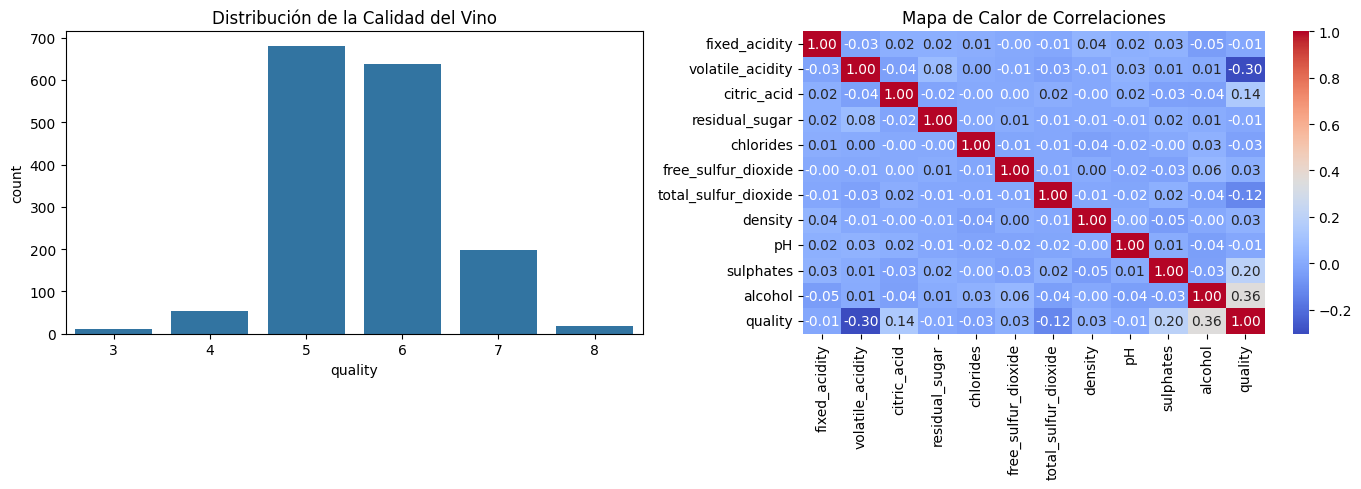

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO Task 4: produce the two required plots here.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1: Distribución del target
sns.countplot(x='quality', data=df, ax=axes[0])
axes[0].set_title('Distribución de la Calidad del Vino')

# 2: Heatmap de correlaciones
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Mapa de Calor de Correlaciones')

plt.tight_layout()
plt.show()




**Your two-sentence observation goes here:**

- (a) La característica con la correlación positiva más fuerte con quality es alcohol.
- (b) Un problema que pasó en los datos es el desbalance de clases, ya que la inmensa mayoría de los registros tienen una calidad de 5 o 6, con poquísimas muestras en las categorías extremas.


## Task 5 — Preprocessing Pipeline (2 pts)

Build a Scikit-learn `Pipeline` with:
- A scaler (`StandardScaler` or `MinMaxScaler` — your choice, **justify in a comment**)
- `LinearRegression` as the final estimator

Then split the data **80/20** with `random_state=42`. **Only fit the Pipeline on the training set.** Any leakage between train and test costs you the full 2 points.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# TODO Task 5:
# 1. Define X (all features except 'quality') and y (the 'quality' column).
X = df.drop('quality', axis=1)
y = df['quality']
# 2. Build the Pipeline. Add a comment justifying your scaler choice.
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
# 3. Split 80/20 with random_state=42.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 4. Fit the Pipeline on the training set only.
pipeline_lr.fit(X_train, y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


## Task 6 — Train & evaluate linear regression (2 pts)

On the **test set**, compute and print three metrics:
- R² (`r2_score`)
- MAE (`mean_absolute_error`)
- RMSE (square root of `mean_squared_error`)

Then, in the markdown cell that follows, write **one sentence**: is the model usable? Reference one of the three metrics to justify.

In [14]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# TODO Task 6: predict on the test set, then print R², MAE, RMSE.
y_pred = pipeline_lr.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")



R²: 0.3162
MAE: 0.5365
RMSE: 0.6726


**Your one-sentence interpretation:**

El modelo tiene una utilidad muy limitada, ya que el métrica del R al cuadrado, suele ser bastante baja en este dataset, lo que indica que las variables independientes no explican gran parte de la varianza del objetivo continuo.


---
# PART C — Logistic Regression (4 pts, ~25 min)


## Task 7 — Engineer a binary target (0.5 pts)

Create a new column `is_good` in `df` defined as `1` if `quality >= 7`, else `0`.

In a comment, state how many samples fall in each class. This matters for Task 9.

In [15]:
# TODO Task 7: create df['is_good'] and report class counts.
df['is_good'] = (df['quality'] >= 7).astype(int)

# Reporte de conteo de clases
print("Conteo de clases para 'is_good':")
print(df['is_good'].value_counts())



Conteo de clases para 'is_good':
is_good
0    1382
1     217
Name: count, dtype: int64


## Task 8 — Train logistic regression with L2 (2 pts)

Build a **second Pipeline** for classification:
- Same scaler as Part B
- `LogisticRegression` with **L2 regularization** (confirm in a comment that L2 is the default) and `max_iter=1000`

Re-split the data 80/20 with `random_state=42` for the new binary target.

On the **test set**, print:
- Accuracy
- F1 score (binary)
- ROC-AUC (use `predict_proba`)
- The Confusion Matrix

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix
)

# TODO Task 8: build the pipeline, split, train, and report all four metrics.
X_bin = df.drop(['quality', 'is_good'], axis=1)
y_bin = df['is_good']

# L2 es la penalización por defecto de LogisticRegression en Scikit-Learn
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='l2', max_iter=1000))
])




## Task 9 — Interpret class imbalance (1 pt)

In the markdown cell below, write **two sentences**:
- (a) Which class is harder to predict (good wines, label 1, or non-good wines, label 0)?
- (b) What does the confusion matrix tell you about *why*?

**Your answer:**

- (a) *…*
- (b) *…*


---
# PART D — Reflection & Submit (1 pt, ~10 min)


## Task 10 — Written reflection (0.5 pts)

In **3–5 sentences**, answer:

> If you had one more hour with this dataset, what would you change first, and why? Reference at least one concept from class (e.g., learning rate, outliers, regularization strength `C`, class imbalance, feature engineering, gradient descent behavior, train/test split strategy).

Generic answers like "I would improve the model" earn zero points. Be specific.

**Your reflection:**

*…*


## Task 11 — Commit, push, submit (0.5 pts)

In the Codespaces terminal:

```bash
git add .
git commit -m "Final exam submission"
git push
```

Then paste your repository URL in Canvas before the 90-minute timer expires.

**Late submissions are not accepted.** The Git commit timestamp is the official submission time.
